# Fraud Detection in Electricity and Gas Consumption Challenge
## ML challenge fraud detection poject

This is a simple starter notebook based on the tutorial prepared by Joy Wawira. Check out the article [here](https://zindi.africa/learn/fraud-detection-in-electricity-and-gas-consumption-challenge-tutorial) for a more detailed description of the steps taken.

This notebook covers:
- Downloading the data straight from Zindi and onto colab
- Loading the data and carrying out simple EDA to understand the data and prepare for modelling 
- Preprocessing the data and feature engineering 
- Creating a simple LGBM model and predicting on the test set
- Prepare submission file and save as csv
- Some tips on how to improve model performance and your score

# Pre-Requisites

In [154]:
import os
import sys
from pathlib import Path

In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [156]:
CURRENT_DIR = Path.cwd()

In [157]:
ROOT_DIR = CURRENT_DIR.parents[0]

In [158]:
DATA_DIR = os.path.join(ROOT_DIR, "data")

TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

In [96]:
DATA_DIR = '/content'

TRAIN_DIR = f'{DATA_DIR}/train'
TEST_DIR = f'{DATA_DIR}/test'

OUTPUT_DIR = f'{DATA_DIR}/output'

## Download and extract files

In [159]:
#only run this cell once, at the start
import requests, os

train_zip = "train.zip"
test_zip = "test.zip"
sample_sub = "SampleSubmission.csv"

# Data Prep

## Import Libraries

In [ ]:
!pip install lightgbm

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm
from lightgbm import LGBMClassifier

import warnings
warnings.simplefilter('ignore')

In [165]:
from pathlib import Path

ROOT_DIR = Path(r"c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project")

for fname in ["client_train.csv", "invoice_train.csv", "client_test.csv", "invoice_test.csv", "SampleSubmission.csv"]:
    print(f"\nSearching for {fname}...")
    matches = list(ROOT_DIR.rglob(fname))
    if matches:
        for m in matches:
            print("FOUND:", m)
    else:
        print("NOT FOUND")



Searching for client_train.csv...
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\client_train.csv
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\train\client_train.csv

Searching for invoice_train.csv...
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\invoice_train.csv
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\train\invoice_train.csv

Searching for client_test.csv...
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\client_test.csv
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\test\client_test.csv

Searching for invoice_test.csv...
FOUND: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter\invoice_test.csv
FOUND: c:\Users\User\Data_scien

In [166]:
TRAIN_DIR = Path(r"...\Fraud_Detection_Starter\train")
TEST_DIR = Path(r"...\Fraud_Detection_Starter\test")
DATA_DIR = Path(r"...\Fraud_Detection_Starter")


In [167]:
from pathlib import Path
import pandas as pd

ROOT_DIR = Path(r"c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project")
DATA_DIR = ROOT_DIR / "data" / "Fraud_Detection_Starter"

TRAIN_DIR = DATA_DIR    # if train/test all in same folder
TEST_DIR = DATA_DIR

print("DATA_DIR:", DATA_DIR)
print("Exists?", DATA_DIR.exists())
print("Files in DATA_DIR:")
for p in DATA_DIR.iterdir():
    print("  -", p.name)

for fname in [
    "client_train.csv",
    "invoice_train.csv",
    "client_test.csv",
    "invoice_test.csv",
    "SampleSubmission.csv",
]:
    fpath = DATA_DIR / fname
    print(f"{fname}: exists? {fpath.exists()}")

client_train = pd.read_csv(TRAIN_DIR / "client_train.csv", low_memory=False)
invoice_train = pd.read_csv(TRAIN_DIR / "invoice_train.csv", low_memory=False)

client_test = pd.read_csv(TEST_DIR / "client_test.csv", low_memory=False)
invoice_test = pd.read_csv(TEST_DIR / "invoice_test.csv", low_memory=False)

sample_submission = pd.read_csv(DATA_DIR / "SampleSubmission.csv", low_memory=False)


DATA_DIR: c:\Users\User\Data_science\repo_folder_kp\week_6\ds-ml-project\data\Fraud_Detection_Starter
Exists? True
Files in DATA_DIR:
  - client_test.csv
  - client_train.csv
  - Fraud_Detection_Starter.ipynb
  - invoice_test.csv
  - invoice_train.csv
  - SampleSubmission.csv
  - test
  - test.zip
  - train
  - train.zip
client_train.csv: exists? True
invoice_train.csv: exists? True
client_test.csv: exists? True
invoice_test.csv: exists? True
SampleSubmission.csv: exists? True


## Read the Data

## Data Understanding

In [168]:
#compare size of the various datasets
print(client_train.shape, invoice_train.shape, client_test.shape, invoice_test.shape)

(135493, 6) (4476749, 16) (58069, 5) (1939730, 16)


In [101]:
#print top rows of dataset
invoice_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [170]:
client_train.shape

(135493, 6)

In [102]:
#print top rows of dataset
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [103]:
#Get a summary for all numerical columns
invoice_train.describe()

,invoice_date,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4476749,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2013-03-18 07:42:34.444128768,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
min,1977-06-09 00:00:00,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2010-01-19 00:00:00,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,2013-07-10 00:00:00,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,2016-09-03 00:00:00,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,2019-12-07 00:00:00,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05
std,NaN,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03


In [104]:
#Get a summary for all numerical columns
client_train.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [105]:
#Get concise information of each column in dataset
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   client_id             object        
 1   invoice_date          datetime64[ns]
 2   tarif_type            int64         
 3   counter_number        int64         
 4   counter_statue        category      
 5   counter_code          int64         
 6   reading_remarque      int64         
 7   counter_coefficient   int64         
 8   consommation_level_1  int64         
 9   consommation_level_2  int64         
 10  consommation_level_3  int64         
 11  consommation_level_4  int64         
 12  old_index             int64         
 13  new_index             int64         
 14  months_number         int64         
 15  counter_type          object        
dtypes: category(1), datetime64[ns](1), int64(12), object(2)
memory usage: 516.6+ MB


In [171]:
invoice_train["invoice_date"] = pd.to_datetime(invoice_train["invoice_date"])


In [172]:
invoice_train["counter_statue"] = invoice_train["counter_statue"].astype("category")



In [108]:
invoice_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype         
---  ------                -----         
 0   client_id             object        
 1   invoice_date          datetime64[ns]
 2   tarif_type            int64         
 3   counter_number        int64         
 4   counter_statue        category      
 5   counter_code          int64         
 6   reading_remarque      int64         
 7   counter_coefficient   int64         
 8   consommation_level_1  int64         
 9   consommation_level_2  int64         
 10  consommation_level_3  int64         
 11  consommation_level_4  int64         
 12  old_index             int64         
 13  new_index             int64         
 14  months_number         int64         
 15  counter_type          object        
dtypes: category(1), datetime64[ns](1), int64(12), object(2)
memory usage: 516.6+ MB


In [109]:
invoice_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [110]:
#Get concise information of each column in dataset
client_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [111]:
client_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [112]:
#Getting unique values on the invoice train data
for col in invoice_train.columns:
    print(f"{col} - {invoice_train[col].nunique()}")

client_id - 135493
invoice_date - 8275
tarif_type - 17
counter_number - 201893
counter_statue - 12
counter_code - 42
reading_remarque - 8
counter_coefficient - 16
consommation_level_1 - 8295
consommation_level_2 - 12576
consommation_level_3 - 2253
consommation_level_4 - 12075
old_index - 155648
new_index - 157980
months_number - 1370
counter_type - 2


In [113]:
#Getting unique values on the invoice train data
for col in client_train.columns:
    print(f"{col} - {client_train[col].nunique()}")

disrict - 4
client_id - 135493
client_catg - 3
region - 25
creation_date - 8088
target - 2


In [114]:
#check for missing values
invoice_train.isnull().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [115]:
#check for missing values
client_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

No missing values in train set

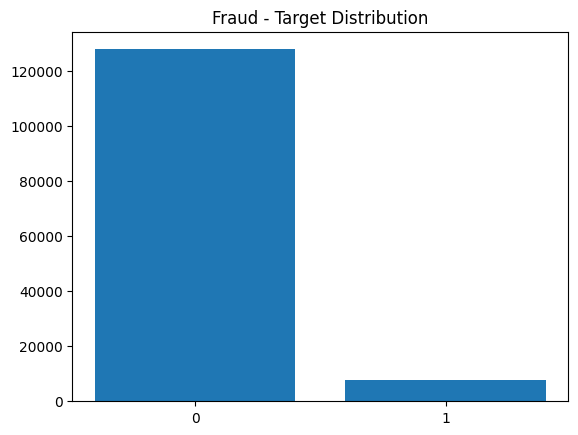

In [116]:
#Visualize fraudulent activities
fraudactivities = client_train.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

Target is highly imbalanced with fewer cases of fraudulent activities

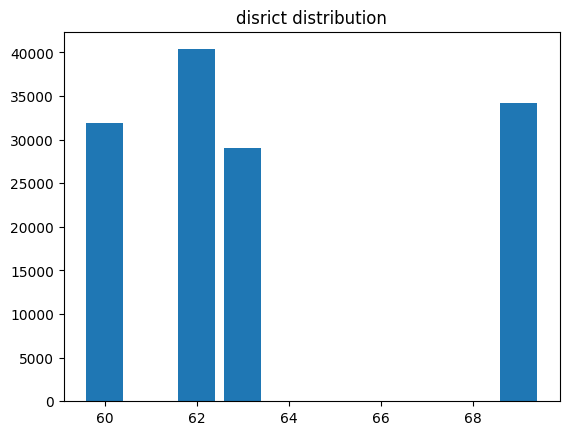

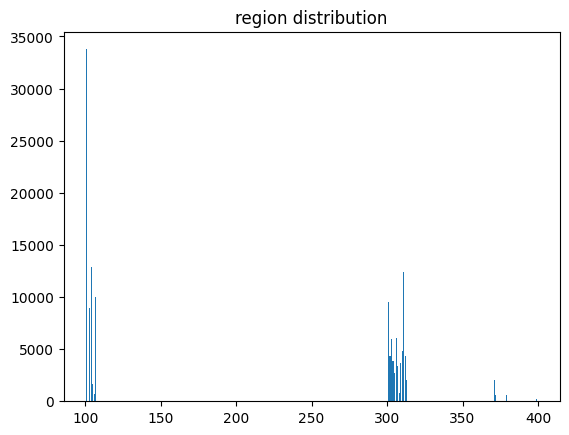

In [117]:
#Visualize client distribution across districts and regions
for col in ['disrict','region']:
    region = client_train.groupby([col])['client_id'].count()
    plt.bar(x=region.index, height=region.values)
    plt.title(col+' distribution')
    plt.show()

# Group invoice data by client_id and Feature Engineering

In [118]:
#Left Join invoice and client data on client_id

invoice_client_merged = pd.merge(
    invoice_train,
    client_train,
    on="client_id",
    how="left"
)


In [173]:
#Check shape before and after
invoice_client_merged.shape


(4476749, 21)

In [175]:
invoice_client_merged.head(50)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,...,0,14302,14384,4,0,60,11,101,31/12/1994,0.0
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,...,0,12294,13678,4,0,60,11,101,31/12/1994,0.0
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,...,0,14624,14747,4,0,60,11,101,31/12/1994,0.0
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,...,0,14747,14849,4,0,60,11,101,31/12/1994,0.0
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,...,0,15066,15638,12,0,60,11,101,31/12/1994,0.0
5,train_Client_0,2017-07-17,11,1335667,0,207,9,1,314,0,...,0,15638,15952,8,0,60,11,101,31/12/1994,0.0
6,train_Client_0,2018-12-07,11,1335667,0,207,9,1,541,0,...,0,15952,16493,12,0,60,11,101,31/12/1994,0.0
7,train_Client_0,2019-03-19,11,1335667,0,207,9,1,585,0,...,0,16493,17078,8,0,60,11,101,31/12/1994,0.0
8,train_Client_0,2011-07-22,11,1335667,0,203,9,1,1200,186,...,0,7770,9156,4,0,60,11,101,31/12/1994,0.0
9,train_Client_0,2011-11-22,11,1335667,0,203,6,1,1082,0,...,0,9156,10238,4,0,60,11,101,31/12/1994,0.0


In [120]:
#Check missing client information after merge
invoice_client_merged.isnull().sum()


client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
disrict                 0
client_catg             0
region                  0
creation_date           0
target                  0
dtype: int64

In [121]:
#Confirm join success
invoice_client_merged["client_id"].nunique()


135493

In [123]:
invoice_client_merged.groupby("target").size()


target
0.0    4123637
1.0     353112
dtype: int64

In [124]:
invoice_client_merged.groupby("target")["client_id"].nunique()


target
0.0    127927
1.0      7566
Name: client_id, dtype: int64

In [151]:
invoice_client_merged.groupby("target").describe()


invoice_date                                                       
              count                           mean                  min   
target                                                                    
0.0         4123637  2013-03-17 15:36:06.284667136  1977-06-09 00:00:00  \
1.0          353112  2013-03-26 03:48:59.359750144  2005-01-07 00:00:00   

                                                                        
                        25%                  50%                  75%   
target                                                                  
0.0     2010-01-15 00:00:00  2013-07-11 00:00:00  2016-09-08 00:00:00  \
1.0     2010-02-09 00:00:00  2013-06-12 00:00:00  2016-07-03 00:00:00   

                                 tarif_type             ... client_catg   
                        max  std      count       mean  ...         max   
target                                                  ...               
0.0     2019-12-07 00:00:00  NaN  4123637.0  20.075281  ...        51.0  \
1.0     2019-12-07 00:00:00  NaN   353112.0  20.744149  ...        51.0   

                     region                                                  
             std      count        mean    min    25%    50%    75%    max   
target                                                                       
0.0     5.588508  4123637.0  209.766559  101.0  103.0  301.0  308.0  399.0  \
1.0     9.620552   353112.0  217.269371  101.0  103.0  302.0  310.0  399.0   

                    
               std  
target              
0.0     103.544302  
1.0     103.782023  

[2 rows x 136 columns]

In [153]:
invoice_client_merged.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,...,0,14302,14384,4,0,60,11,101,31/12/1994,0.0
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,...,0,12294,13678,4,0,60,11,101,31/12/1994,0.0
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,...,0,14624,14747,4,0,60,11,101,31/12/1994,0.0
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,...,0,14747,14849,4,0,60,11,101,31/12/1994,0.0
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,...,0,15066,15638,12,0,60,11,101,31/12/1994,0.0


In [127]:
invoice_client_merged["counter_type"] = (
    invoice_client_merged["counter_type"]
    .map({"ELEC": 0, "GAZ": 1})
)


In [128]:
invoice_client_merged["counter_type"].value_counts()


counter_type
0    3079406
1    1397343
Name: count, dtype: int64

In [149]:
invoice_client_merged["disrict"].dtype


dtype('int64')

In [150]:
invoice_client_merged.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,...,consommation_level_4,old_index,new_index,months_number,counter_type,disrict,client_catg,region,creation_date,target
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,...,0,14302,14384,4,0,60,11,101,31/12/1994,0.0
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,...,0,12294,13678,4,0,60,11,101,31/12/1994,0.0
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,...,0,14624,14747,4,0,60,11,101,31/12/1994,0.0
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,...,0,14747,14849,4,0,60,11,101,31/12/1994,0.0
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,...,0,15066,15638,12,0,60,11,101,31/12/1994,0.0


In [177]:
def aggregate_by_client_id(invoice_data):
    aggs = {}
    aggs['consommation_level_1'] = ['mean']
    aggs['consommation_level_2'] = ['mean']
    aggs['consommation_level_3'] = ['mean']
    aggs['consommation_level_4'] = ['mean']

    agg_trans = invoice_data.groupby(['client_id']).agg(aggs)
    agg_trans.columns = ['_'.join(col).strip() for col in agg_trans.columns.values]
    agg_trans.reset_index(inplace=True)

    df = (invoice_data.groupby('client_id')
            .size()
            .reset_index(name='{}transactions_count'.format('1')))
    return pd.merge(df, agg_trans, on='client_id', how='left')

In [180]:
#group invoice data by client_id
agg_train = aggregate_by_client_id(invoice_client_merged)

In [181]:
print(agg_train.shape)
agg_train.head()

(135493, 6)


,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [182]:
#aggregate test set
agg_test = aggregate_by_client_id(invoice_test)
test = pd.merge(client_test,agg_test, on='client_id', how='left')

In [185]:
agg_train.shape, test.shape

((135493, 6), (58069, 10))

In [186]:
agg_train.head()

,client_id,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,train_Client_0,35,352.400000,10.571429,0.000000,0.000000
1,train_Client_1,37,557.540541,0.000000,0.000000,0.000000
2,train_Client_10,18,798.611111,37.888889,0.000000,0.000000
3,train_Client_100,20,1.200000,0.000000,0.000000,0.000000
4,train_Client_1000,14,663.714286,104.857143,117.357143,36.714286


In [187]:
test.head()

,disrict,client_id,client_catg,region,creation_date,1transactions_count,consommation_level_1_mean,consommation_level_2_mean,consommation_level_3_mean,consommation_level_4_mean
0,62,test_Client_0,11,307,28/05/2002,37,488.135135,3.243243,0.000000,0.000000
1,69,test_Client_1,11,103,06/08/2009,22,1091.409091,843.136364,182.318182,586.318182
2,62,test_Client_10,11,310,07/04/2004,74,554.040541,37.364865,15.743243,0.162162
3,60,test_Client_100,11,101,08/10/1992,40,244.350000,0.000000,0.000000,0.000000
4,62,test_Client_1000,11,301,21/07/1977,53,568.188679,145.056604,33.679245,0.000000
